In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



/tmp/ipykernel_727134/3280854012.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['-20%', '-10%', '+0%', '+10%', '+20%'], fontsize=14)
/tmp/ipykernel_727134/3280854012.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['-20%', '-10%', '+0%', '+10%', '+20%'], fontsize=14)
/tmp/ipykernel_727134/3280854012.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['-20%', '-10%', '+0%', '+10%', '+20%'], fontsize=14)


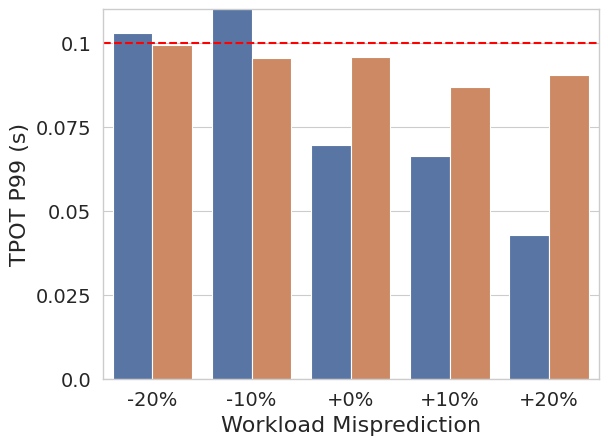

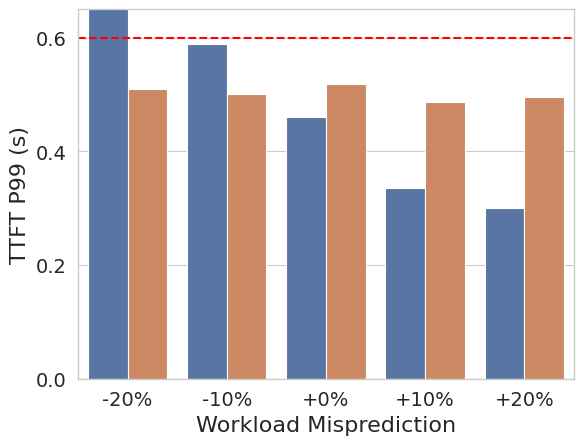

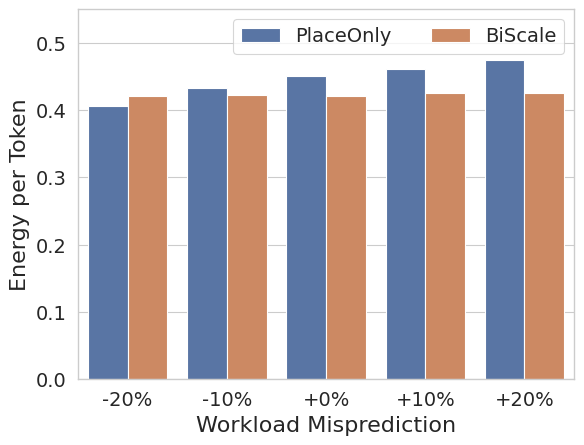

In [30]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/synthetic_char_balance/metrics.csv"
df_results_actual = pd.read_csv(path)

path = '/export2/obasit/ClusterLevelServing/vllm_logs/4_nodes_logs_together_ai/kube_results_first_version_failed/profiler_logs_0/placeonly_disag/metrics.csv'
df_results_over_under_plain = pd.read_csv(path)

path = '/export2/obasit/ClusterLevelServing/vllm_logs/4_nodes_logs_together_ai/kube_results_first_version_failed/profiler_logs_0/dvfs_disag/metrics.csv'
df_results_over_under_dvfs = pd.read_csv(path)

df_results = pd.concat([df_results_actual, df_results_over_under_plain, df_results_over_under_dvfs], ignore_index=True)

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'OURS_R5_JAN3_B5_3_OVER20_node0': 'PlaceOnly +20',
    'OURS_R5_JAN3_B5_3_OVER10_node0': 'PlaceOnly +10',
    'OURS_R5_JAN3_B5_3': 'PlaceOnly +0',
    'OURS_R5_JAN3_B5_3_UNDER10_node0': 'PlaceOnly -10',
    'OURS_R5_JAN3_B5_3_UNDER20_node0': 'PlaceOnly -20',

    'OURS_R5_JAN3_B5_3_OVER20_DVFS_node0': 'BiScale +20',
    'OURS_R5_JAN3_B5_3_OVER10_DVFS_node0': 'BiScale +10',
    'OURS_R5_JAN3_B5_3_DVFS_W': 'BiScale +0',
    'OURS_R5_JAN3_B5_3_UNDER10_DVFS_node0': 'BiScale -10',
    'OURS_R5_JAN3_B5_3_UNDER20_DVFS_node0': 'BiScale -20',

}

# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)

df_results = df_results[df_results["instance"] == "total"]
valid_expr_dirs = set(rename_mapping.values())
df_results = df_results[df_results["expr_dir"].isin(valid_expr_dirs)].copy()


# Extract RPS and name from expr_dir
df_results['mispredict'] = df_results['expr_dir'].str.extract(r'([+-]?\d+)$', expand=False).astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+[+-]\d+$', '', regex=True)

# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['PlaceOnly', 'BiScale'], ordered=True)

#################### TPOT P99 ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="mispredict", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Workload Misprediction', fontsize=16)
ax.set_ylabel('TPOT P99 (s)', fontsize=16)
ax.set_ylim(0, 0.11)
ax.set_xticklabels(['-20%', '-10%', '+0%', '+10%', '+20%'], fontsize=14)
ax.set_yticks([0.0, 0.025, 0.05, 0.075, 0.1])
ax.set_yticklabels(['0.0', '0.025', '0.05', '0.075', '0.1'], fontsize=14)
ax.legend_.remove()
plt.savefig("figs/disag_mispred_tpot.pdf", format="pdf")

#################### TTFT P99 ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="mispredict", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Workload Misprediction', fontsize=16)
ax.set_ylabel('TTFT P99 (s)', fontsize=16)
ax.set_ylim(0, 0.65)
ax.set_xticklabels(['-20%', '-10%', '+0%', '+10%', '+20%'], fontsize=14)
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6'], fontsize=14)
ax.legend_.remove()
plt.savefig("figs/disag_mispred_ttft.pdf", format="pdf")

# #################### Energy per token ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="mispredict", 
    y="energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True
)

# Customize the plot
ax.set_xlabel('Workload Misprediction', fontsize=16)
ax.set_ylabel('Energy per Token', fontsize=16)
ax.set_ylim(0, 0.55)
ax.set_xticklabels(['-20%', '-10%', '+0%', '+10%', '+20%'], fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend_.set_title('')
ax.legend(fontsize=14, ncol=2)
plt.savefig("figs/disag_mispred_energy_per_token.pdf", format="pdf")